# Jobsheet 10 - SVM dan Naive Bayes
Berisi implementasi 3 percobaan: SVM (klasifikasi), SVR (regresi), dan Naive Bayes (klasifikasi).

## Percobaan 1: Support Vector Machine (SVM)
Dataset: Pima Indian Diabetes (klasifikasi diabetes berdasarkan data medis numerik).

In [19]:
# Import library dasar
import pandas as pd

# Load dataset (upload file diabetes.csv ke Colab terlebih dahulu)
df = pd.read_csv('diabetes.csv')
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


`pd.read_csv` membaca file CSV lalu mengubahnya menjadi DataFrame. `df.head()` menampilkan 5 baris pertama untuk melihat sekilas isi data.

In [20]:
# Cek missing value dan tipe data tiap kolom
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


`df.info()` menampilkan jumlah data non-null dan tipe data tiap kolom. Jika semua kolom lengkap (non-null count = jumlah baris) dan bertipe numerik (int64/float64), data siap dipakai tanpa perlu imputasi atau encoding.

In [21]:
# Pisahkan atribut (fitur) dan label
X = df.drop(columns=['Outcome'])   # semua kolom kecuali label
y = df['Outcome']                  # kolom label (0 = tidak diabetes, 1 = diabetes)

`X` berisi seluruh atribut prediktor, `y` berisi target/label yang ingin diprediksi (kolom `Outcome`).

In [22]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Bagi data latih dan data uji (80:20)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Standarisasi skala fitur (mean=0, std=1)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

Standarisasi diperlukan karena SVM sensitif terhadap skala data — atribut dengan rentang nilai besar (misal Glucose) bisa mendominasi atribut dengan rentang kecil (misal DiabetesPedigreeFunction) jika tidak distandarisasi.

In [23]:
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score

# Buat dan latih model SVM
clf = SVC(kernel='rbf', C=1, gamma='scale', random_state=42)
clf.fit(X_train, y_train)

# Prediksi dan evaluasi akurasi
y_pred = clf.predict(X_test)
print('Akurasi SVM:', accuracy_score(y_test, y_pred))

Akurasi SVM: 0.7337662337662337


**Penjelasan parameter SVC:**
- `kernel='rbf'`: fungsi kernel Radial Basis Function, cocok untuk data yang tidak dapat dipisahkan secara linear.
- `C`: parameter regularisasi. Semakin besar `C`, model semakin berusaha mengklasifikasikan semua data latih dengan benar (margin lebih ketat) sehingga risiko *overfitting* naik. Semakin kecil `C`, margin lebih lebar tapi bisa *underfitting*.
- `gamma`: menentukan seberapa jauh pengaruh satu titik data. `gamma` besar → pengaruh hanya ke titik terdekat (model lebih kompleks, rawan overfitting); `gamma` kecil → pengaruh lebih menyebar (model lebih sederhana).

**Analisis:** Menaikkan `C` dan `gamma` tidak selalu meningkatkan akurasi pada data uji — pada nilai tertentu akurasi data latih naik tapi akurasi data uji bisa turun karena overfitting. Perlu dicoba beberapa kombinasi (grid search) untuk menemukan nilai optimal.

In [24]:
# (Opsional) Percobaan tuning sederhana untuk melihat pengaruh C dan gamma
for C in [0.1, 1, 10, 100]:
    model = SVC(kernel='rbf', C=C, gamma='scale', random_state=42)
    model.fit(X_train, y_train)
    acc = accuracy_score(y_test, model.predict(X_test))
    print(f'C={C:<6} -> akurasi = {acc:.4f}')

C=0.1    -> akurasi = 0.7468
C=1      -> akurasi = 0.7338
C=10     -> akurasi = 0.7143
C=100    -> akurasi = 0.6818


## Percobaan 2: Support Vector Regression (SVR)
Dataset: lama kerja (tahun pengalaman) vs gaji.

In [25]:
import pandas as pd
import numpy as np

df2 = pd.read_csv('Salary_Data.csv')
df2.info()
df2.head()

<class 'pandas.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 2 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   YearsExperience  30 non-null     float64
 1   Salary           30 non-null     float64
dtypes: float64(2)
memory usage: 612.0 bytes


,YearsExperience,Salary
0,1.1,39343.0
1,1.3,46205.0
2,1.5,37731.0
3,2.0,43525.0
4,2.2,39891.0


Sama seperti sebelumnya, `.info()` dipakai untuk memastikan tidak ada *missing value* sebelum data dipakai untuk pelatihan.

In [26]:
# Pisahkan atribut dan label
X2 = df2['YearsExperience'].values.reshape(-1, 1)  # reshape karena hanya 1 fitur
y2 = df2['Salary'].values

`reshape(-1, 1)` mengubah array 1 dimensi menjadi array 2 dimensi (baris x 1 kolom) karena SKLearn mengharuskan input `X` berbentuk matriks meskipun hanya ada satu fitur.

In [27]:
from sklearn.svm import SVR

svr = SVR(kernel='rbf', C=1000, gamma=0.05)
svr.fit(X2, y2)

,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",0.05
,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive.The penalty is a squared l2. For an intuitive visualization of theeffects of scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1000
,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm.If none is given, 'rbf' will be used. If a callable is given it isused to precompute the kernel matrix.For an intuitive visualization of different kernel typessee :ref:`sphx_glr_auto_examples_svm_plot_svm_regression.py`",'rbf'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"epsilon epsilon: float, default=0.1Epsilon in the epsilon-SVR model. It specifies the epsilon-tubewithin which no penalty is associated in the training loss functionwith points predicted within a distance epsilon from the actualvalue. Must be non-negative.",0.1
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide <shrinking_svm>`.",True
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"verbose verbose: bool, default=FalseEnable verbose output. Note that this setting takes advantage of aper-process runtime setting in libsvm that, if enabled, may not workproperly in a multithreaded context.",False
,"max_iter max_iter: int, default=-1Hard limit on iterations within solver, or -1 for no limit.",-1


**Penjelasan parameter:**
- `C=1000`: nilai besar membuat model berusaha mengikuti data latih sedekat mungkin (toleransi error kecil).
- `gamma=0.05`: nilai kecil membuat pengaruh tiap titik data menyebar lebih luas, menghasilkan kurva yang lebih halus (smooth).

**Analisis:** Menaikkan `C` terlalu tinggi membuat model mengikuti *noise* pada data (overfitting) sehingga hasil prediksi pada data baru bisa kurang akurat, meskipun kurva terlihat pas dengan data latih. Sebaliknya, `C` terlalu kecil membuat model terlalu sederhana (underfitting) dan tidak mampu menangkap pola data.

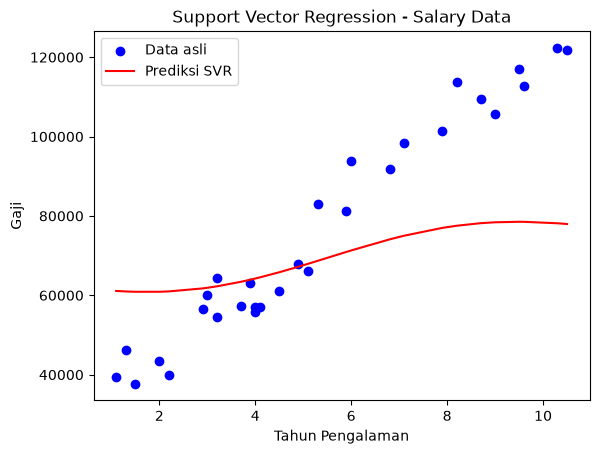

In [28]:
import matplotlib.pyplot as plt

plt.scatter(X2, y2, color='blue', label='Data asli')
plt.plot(X2, svr.predict(X2), color='red', label='Prediksi SVR')
plt.xlabel('Tahun Pengalaman')
plt.ylabel('Gaji')
plt.title('Support Vector Regression - Salary Data')
plt.legend()
plt.show()

## Percobaan 3: Naive Bayes
Dataset: iklan_sosmed.csv (umur, gaji, jenis kelamin) untuk memprediksi transaksi.

In [29]:
import pandas as pd

df3 = pd.read_csv('iklan_sosmed.csv', delimiter=';')
df3.head()

,ID,Jenis_Kelamin,Umur,Gaji,Transaksi
0,15624510,Pria,19,285000000,0
1,15810944,Pria,35,300000000,0
2,15668575,Wanita,26,645000000,0
3,15603246,Wanita,27,855000000,0
4,15804002,Pria,19,1140000000,0


Parameter `delimiter=';'` digunakan karena file CSV ini menggunakan titik koma sebagai pemisah kolom, bukan koma.

In [30]:
# Pisahkan fitur (umur, gaji) dan label (Transaksi)
X3 = df3.iloc[:, 2:-1].values
y3 = df3.iloc[:, -1].values

`iloc[:, 2:-1]` memilih kolom umur dan gaji (mengabaikan kolom identitas dan jenis kelamin), sedangkan `iloc[:, -1]` mengambil kolom label terakhir (Transaksi).

In [31]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler

X3_train, X3_test, y3_train, y3_test = train_test_split(
    X3, y3, test_size=0.2, random_state=42
)

scaler3 = MinMaxScaler()
X3_train = scaler3.fit_transform(X3_train)
X3_test = scaler3.transform(X3_test)

`MinMaxScaler` menormalkan data ke rentang 0-1, diperlukan karena rentang nilai umur dan gaji berbeda jauh (misal umur puluhan, gaji jutaan).

In [32]:
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import confusion_matrix, accuracy_score

nb = GaussianNB()
nb.fit(X3_train, y3_train)

y3_pred = nb.predict(X3_test)
cm = confusion_matrix(y3_test, y3_pred)
print('Confusion Matrix:\n', cm)
print('Akurasi Naive Bayes:', accuracy_score(y3_test, y3_pred))

Confusion Matrix:
 [[50  2]
 [ 3 25]]
Akurasi Naive Bayes: 0.9375


`GaussianNB` dipilih karena fitur (umur, gaji) berupa data numerik kontinu yang diasumsikan berdistribusi normal. Confusion matrix menunjukkan jumlah prediksi benar/salah untuk tiap kelas, dan `accuracy_score` menghitung persentase prediksi yang benar secara keseluruhan.

C:\Users\FAQIH\AppData\Local\Temp\ipykernel_21392\536865033.py:14: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  plt.scatter(X_set[y_set == j, 0], X_set[y_set == j, 1],


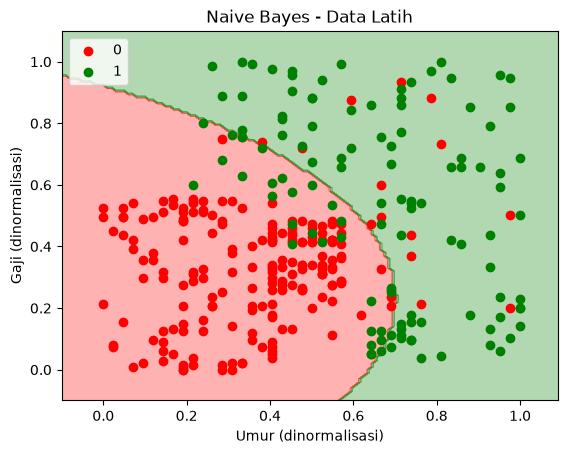

C:\Users\FAQIH\AppData\Local\Temp\ipykernel_21392\536865033.py:14: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  plt.scatter(X_set[y_set == j, 0], X_set[y_set == j, 1],


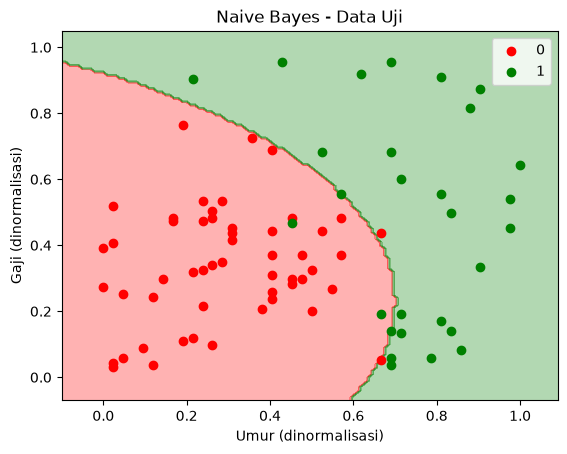

In [33]:
from matplotlib.colors import ListedColormap
import matplotlib.pyplot as plt
import numpy as np

def plot_decision_boundary(X, y, model, title):
    X_set, y_set = X, y
    X1, X2 = np.meshgrid(
        np.arange(X_set[:, 0].min() - 0.1, X_set[:, 0].max() + 0.1, 0.01),
        np.arange(X_set[:, 1].min() - 0.1, X_set[:, 1].max() + 0.1, 0.01)
    )
    plt.contourf(X1, X2, model.predict(np.array([X1.ravel(), X2.ravel()]).T).reshape(X1.shape),
                 alpha=0.3, cmap=ListedColormap(('red', 'green')))
    for i, j in enumerate(np.unique(y_set)):
        plt.scatter(X_set[y_set == j, 0], X_set[y_set == j, 1],
                    c=ListedColormap(('red', 'green'))(i), label=j)
    plt.title(title)
    plt.xlabel('Umur (dinormalisasi)')
    plt.ylabel('Gaji (dinormalisasi)')
    plt.legend()
    plt.show()

plot_decision_boundary(X3_train, y3_train, nb, 'Naive Bayes - Data Latih')
plot_decision_boundary(X3_test, y3_test, nb, 'Naive Bayes - Data Uji')

## Kesimpulan
1. SVM dengan kernel RBF mampu mengklasifikasikan data diabetes dengan cukup baik setelah dilakukan standarisasi fitur, namun pemilihan parameter `C` dan `gamma` yang terlalu besar berisiko menyebabkan overfitting.
2. SVR dapat digunakan untuk memodelkan hubungan non-linear antara pengalaman kerja dan gaji, tetapi hasil kurva sangat bergantung pada kombinasi parameter `C` dan `gamma` yang dipilih.
3. Naive Bayes (Gaussian) memberikan akurasi yang cukup tinggi untuk data numerik seperti umur dan gaji, dan performanya masih dapat ditingkatkan lagi dengan hyperparameter tuning atau penambahan fitur.

## Saran
1. Sebaiknya dilakukan *hyperparameter tuning* (misalnya dengan `GridSearchCV`) untuk mendapatkan kombinasi parameter terbaik pada ketiga algoritma.
2. Perlu dicoba kernel lain (linear, polynomial) pada SVM/SVR untuk membandingkan performa dengan kernel RBF.
3. Dataset dengan jumlah data lebih besar dapat digunakan agar evaluasi model lebih representatif.